In [2]:
pip install pillow


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


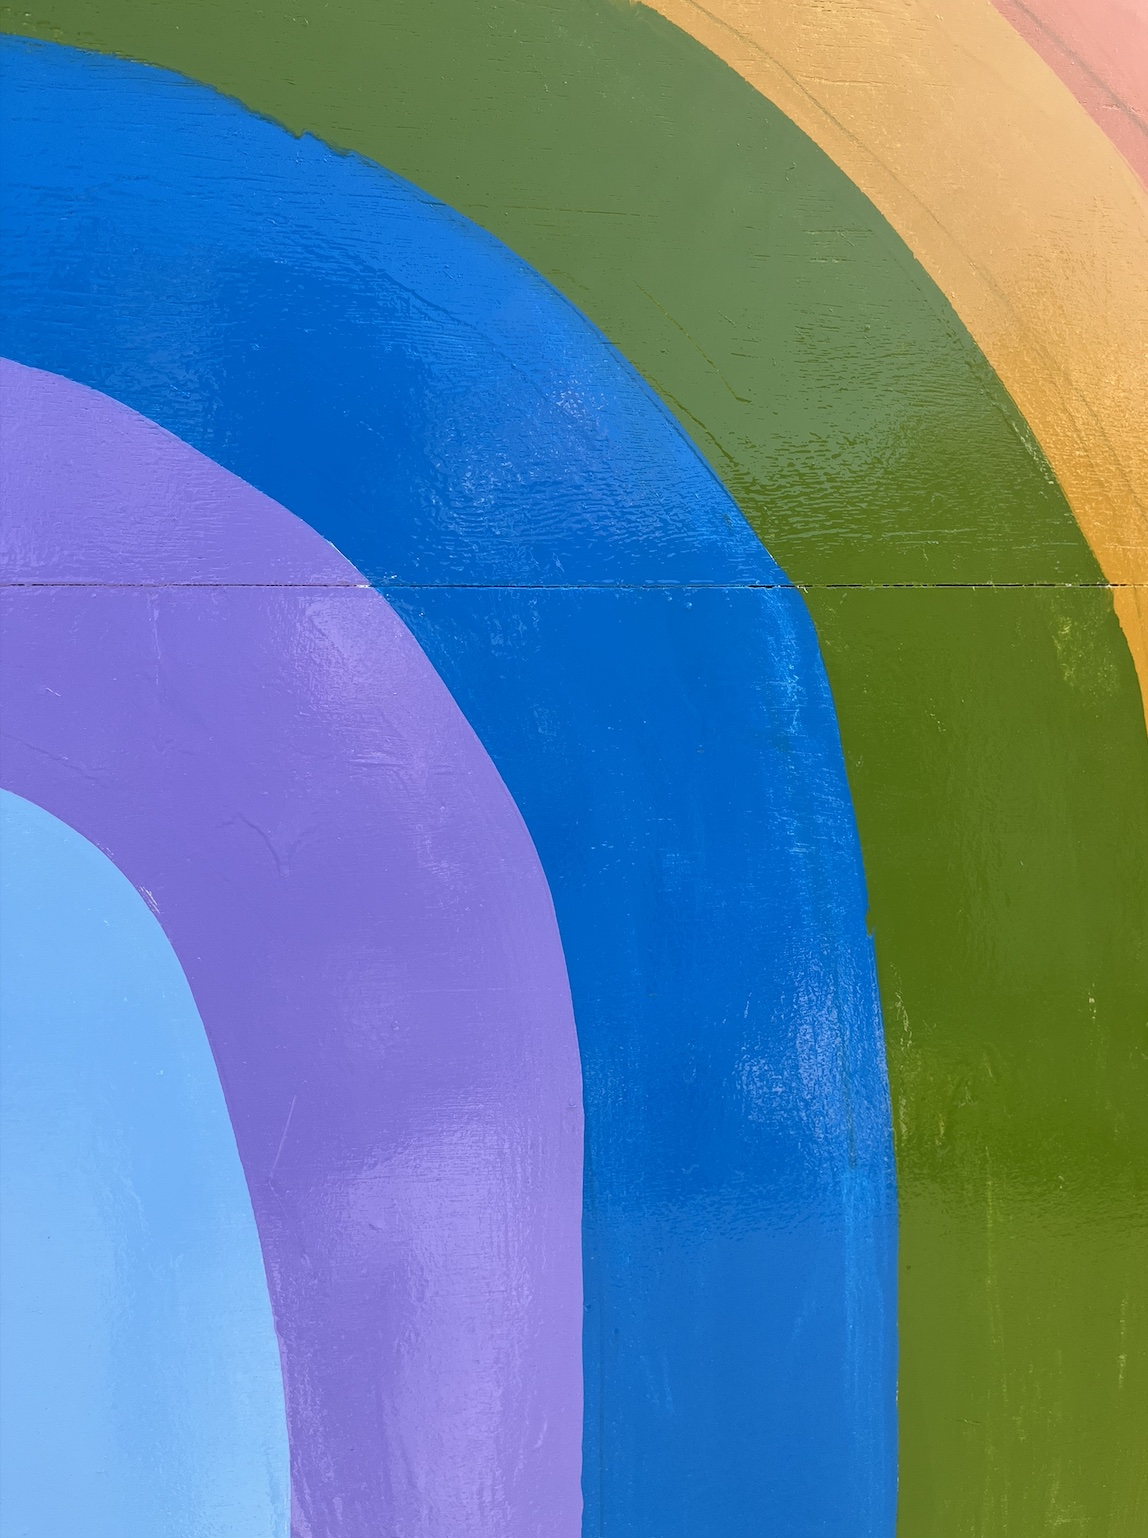

Image Format: JPEG
Image Size: (1148, 1538)
Image Mode: RGB
Shape of the image array: (1538, 1148, 3)
[[ 82  83  83 ... 251 251 250]
 [ 80  83  84 ... 248 249 248]
 [ 84  86  86 ... 248 249 250]
 ...
 [131 131 131 ... 112 113 113]
 [125 135 132 ... 113 112 110]
 [125 135 132 ... 114 113 111]]


array([[ 82,  83,  83, ..., 251, 251, 250],
       [ 80,  83,  84, ..., 248, 249, 248],
       [ 84,  86,  86, ..., 248, 249, 250],
       ...,
       [131, 131, 131, ..., 112, 113, 113],
       [125, 135, 132, ..., 113, 112, 110],
       [125, 135, 132, ..., 114, 113, 111]], dtype=uint8)

[[111 112 112 ... 189 189 188]
 [109 112 113 ... 186 187 186]
 [111 113 113 ... 186 187 188]
 ...
 [183 183 183 ... 128 129 129]
 [177 187 184 ... 129 128 126]
 [177 187 184 ... 130 129 127]]


array([[111, 112, 112, ..., 189, 189, 188],
       [109, 112, 113, ..., 186, 187, 186],
       [111, 113, 113, ..., 186, 187, 188],
       ...,
       [183, 183, 183, ..., 128, 129, 129],
       [177, 187, 184, ..., 129, 128, 126],
       [177, 187, 184, ..., 130, 129, 127]], dtype=uint8)

[[ 57  58  58 ... 176 176 175]
 [ 55  58  59 ... 173 174 173]
 [ 56  58  58 ... 173 174 175]
 ...
 [241 241 241 ...  39  40  40]
 [235 245 242 ...  40  39  37]
 [235 245 242 ...  41  40  38]]


array([[ 57,  58,  58, ..., 176, 176, 175],
       [ 55,  58,  59, ..., 173, 174, 173],
       [ 56,  58,  58, ..., 173, 174, 175],
       ...,
       [241, 241, 241, ...,  39,  40,  40],
       [235, 245, 242, ...,  40,  39,  37],
       [235, 245, 242, ...,  41,  40,  38]], dtype=uint8)

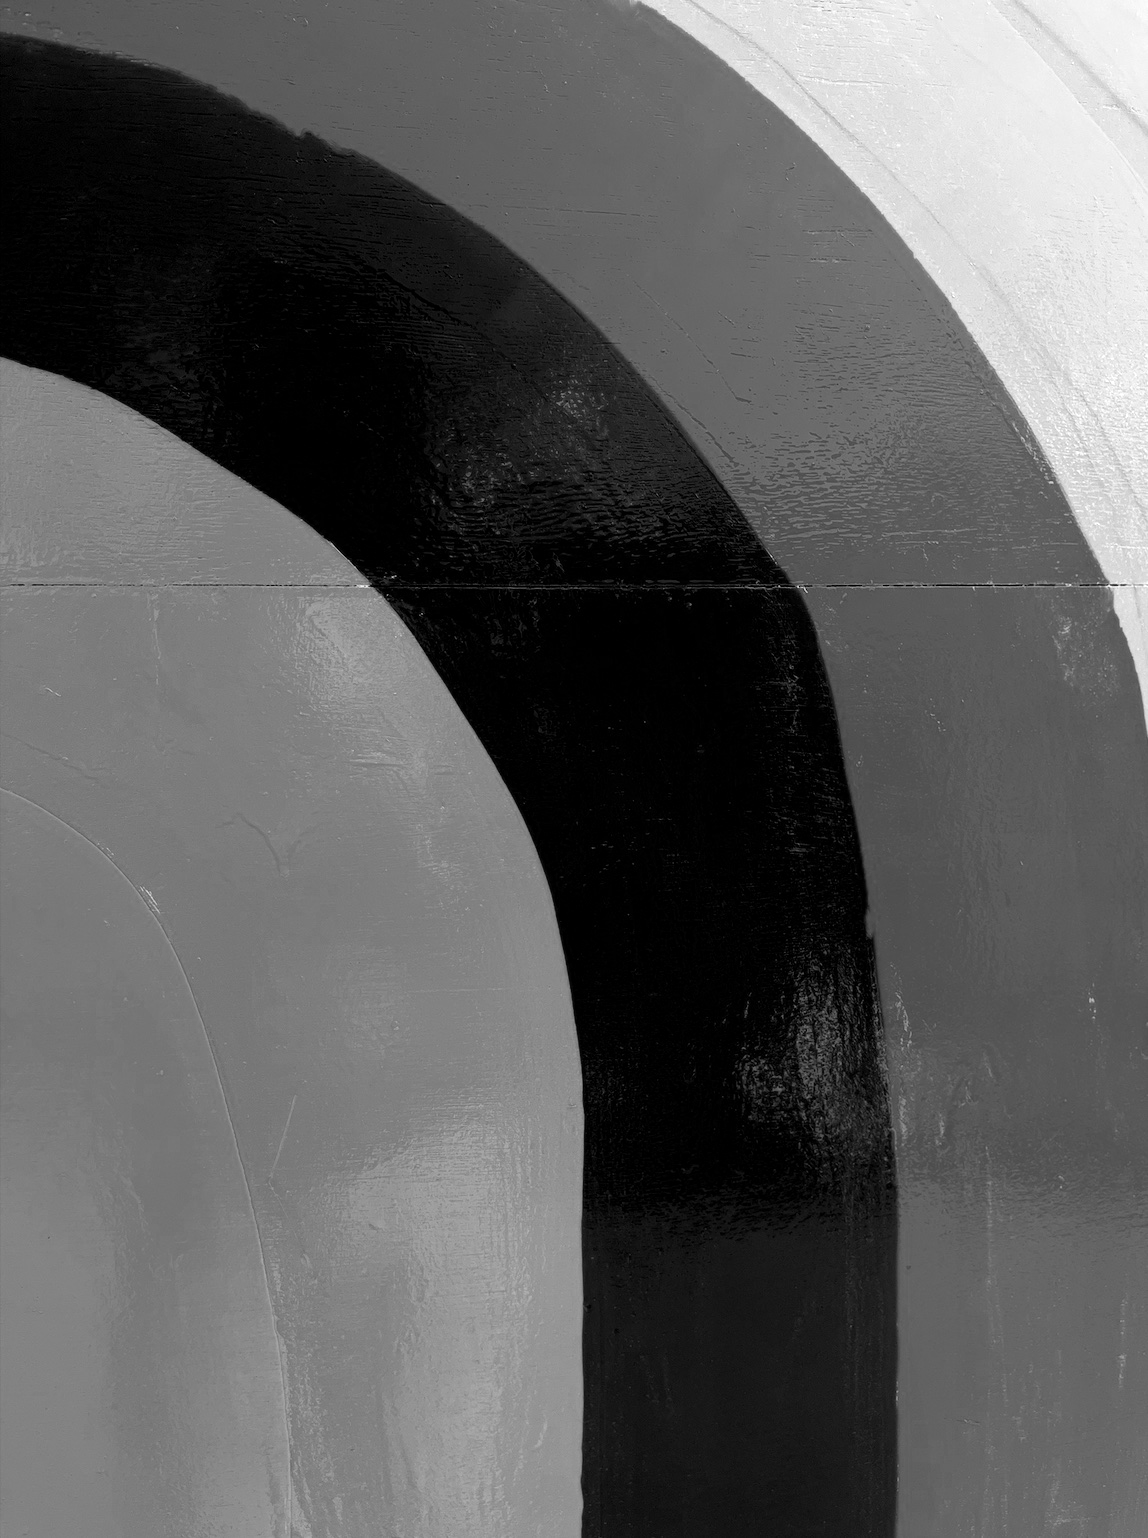

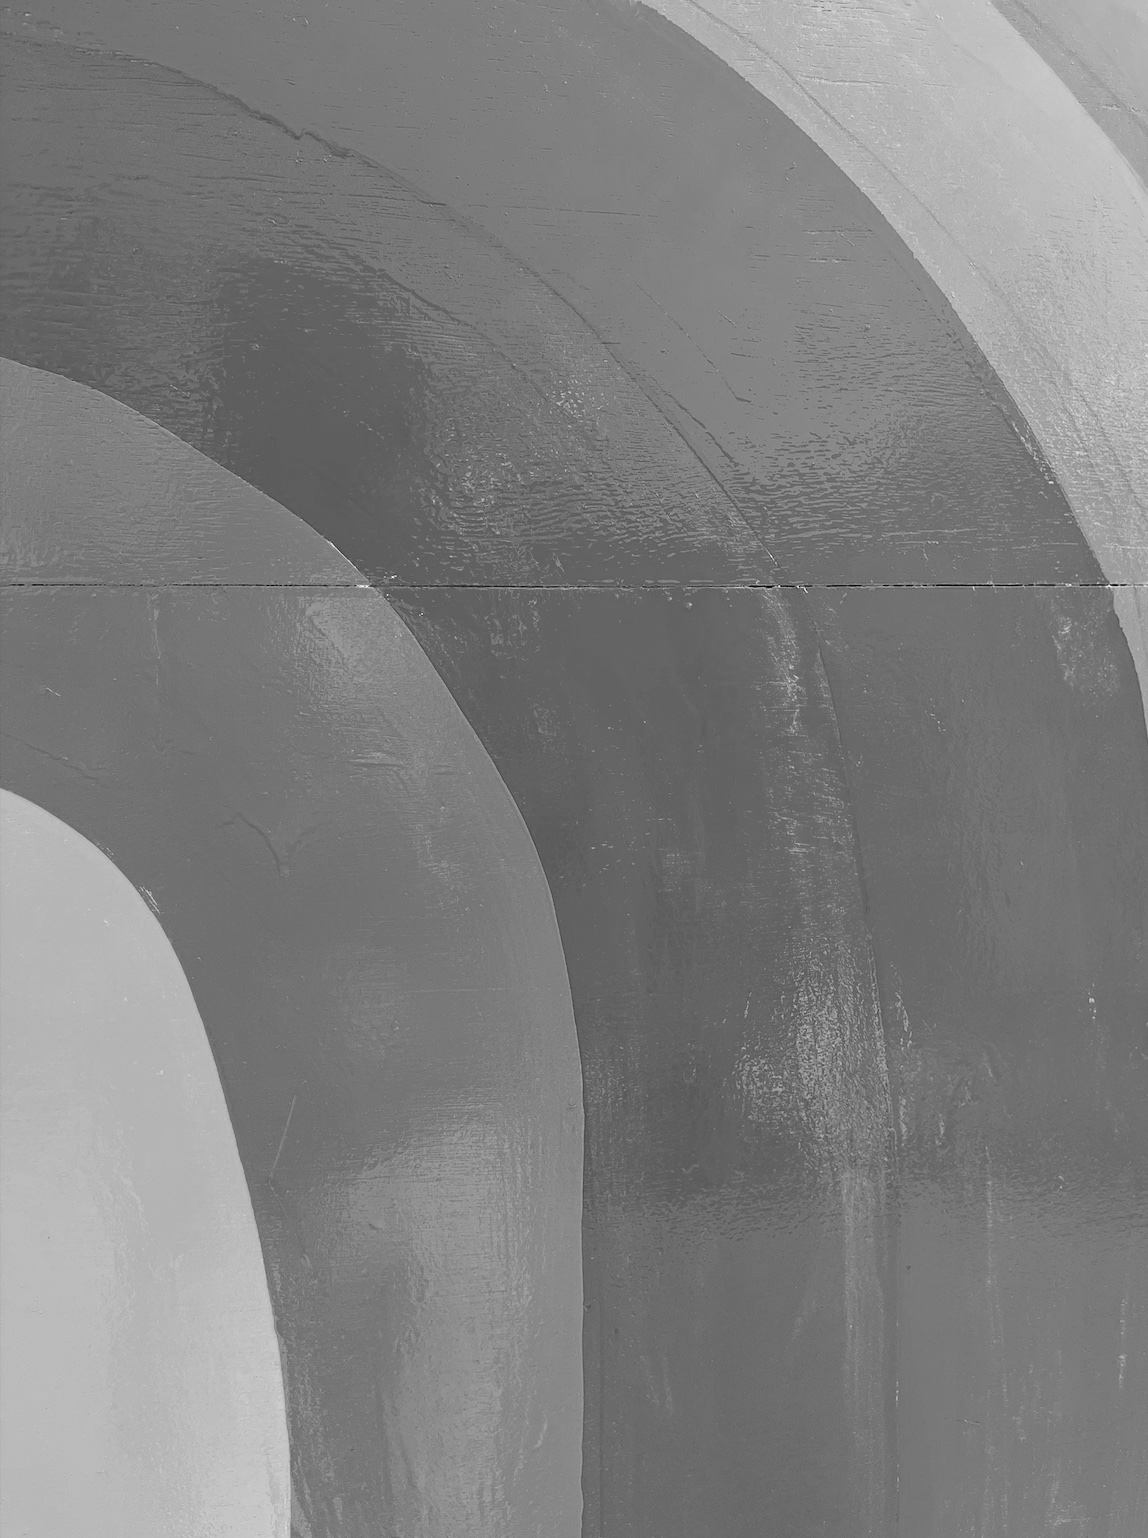

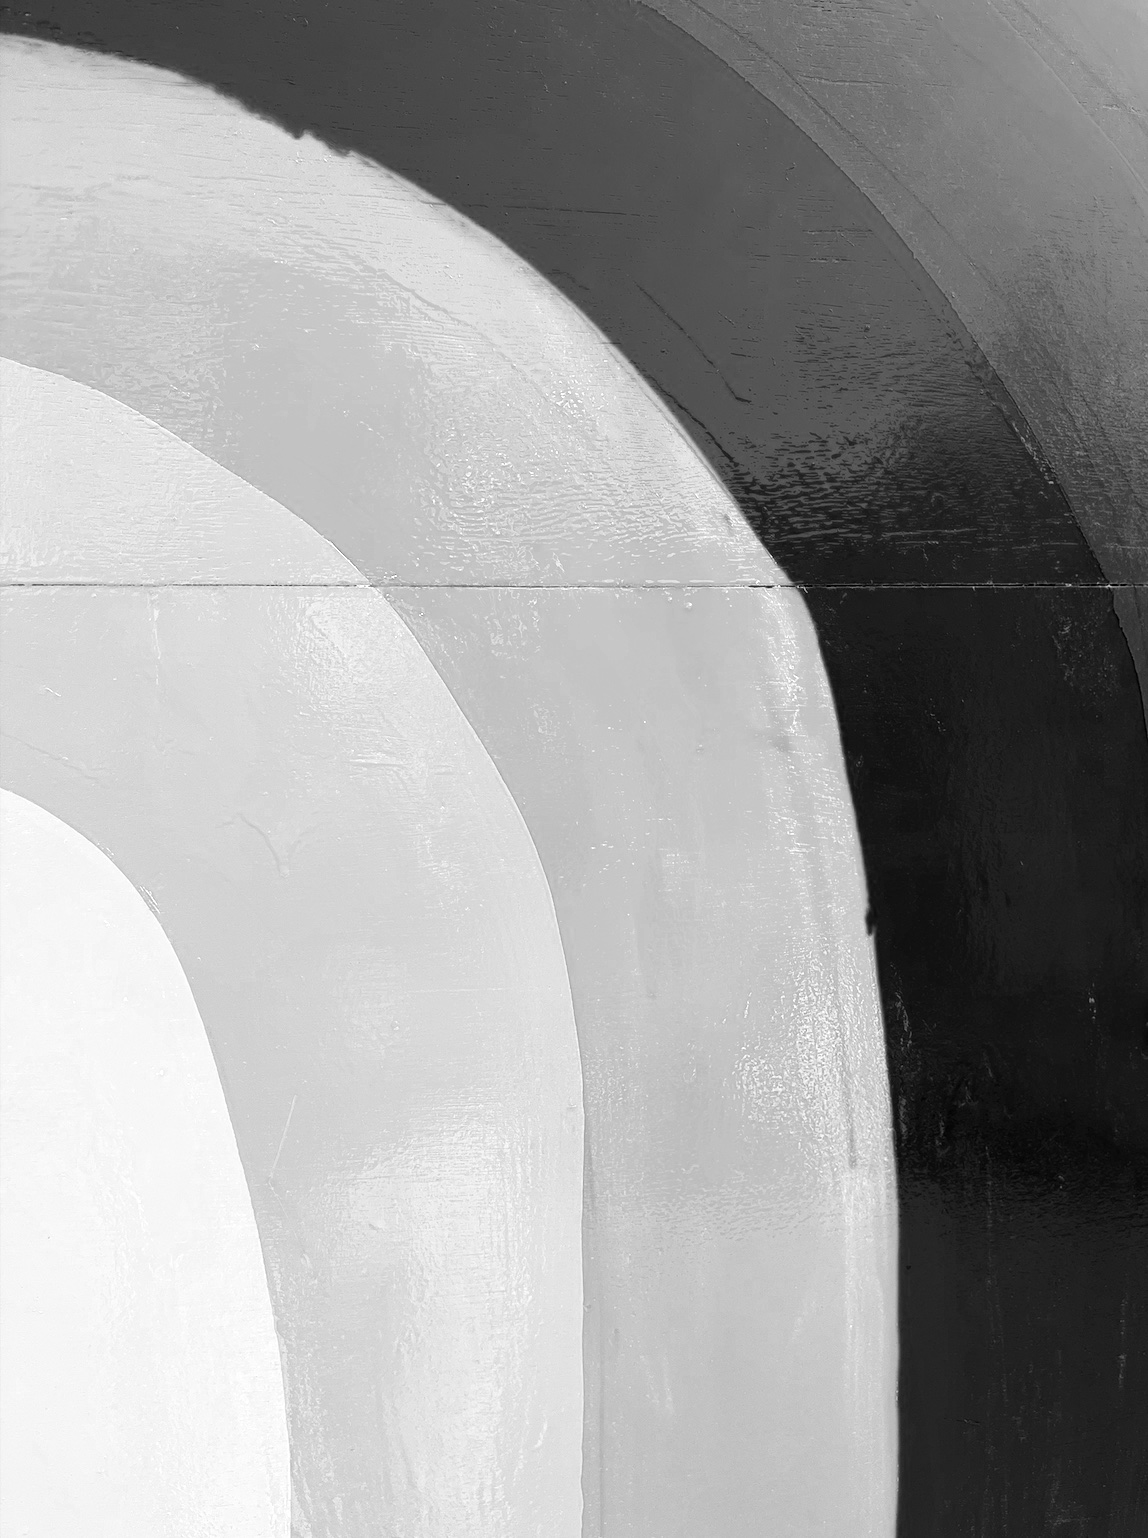

Row 100 shape: (1148, 3)
Column 50 shape: (1538, 3)
Pixel at (10,20): [ 89 116  63]


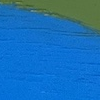

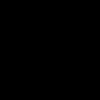

In [3]:
from PIL import Image
from IPython.display import display
import numpy as np

# open image
image_grayed = Image.open("/content/drive/MyDrive/AI ML/Data/image.jpg")

# display image
display(image_grayed)

# image info
print("Image Format:", image_grayed.format)
print("Image Size:", image_grayed.size)
print("Image Mode:", image_grayed.mode)

# Convert grayscale → RGB (important for channels)
image_colored = image_grayed.convert("RGB")

# Convert to NumPy array
image_array_colored = np.array(image_colored)

# print shape
print("Shape of the image array:", image_array_colored.shape)

# Red channel
red_channel = image_array_colored[:, :, 0]
print(red_channel)
display(red_channel)

# Green channel
green_channel = image_array_colored[:, :, 1]
print(green_channel)
display(green_channel)

# Blue channel
blue_channel = image_array_colored[:, :, 2]
print(blue_channel)
display(blue_channel)

r, g, b = image_colored.split()

# Display individual channels
display(r)
display(g)
display(b)

image_array = image_array_colored

# Accessing a specific row — 100th row
row_100 = image_array[100, :, :]
print("Row 100 shape:", row_100.shape)

# Accessing a specific column — 50th column
col_50 = image_array[:, 50, :]
print("Column 50 shape:", col_50.shape)

# Accessing a specific pixel (row 10, col 20)
pixel = image_array[10, 20, :]  # RGB values at (10,20)
print("Pixel at (10,20):", pixel)


# ===============================
# Extracting sub-image (cropping) using PIL
# ===============================

# Define cropping box (left, upper, right, lower)
left, upper, right, lower = 100, 50, 200, 150

# Crop the image
cropped_image = image_colored.crop((left, upper, right, lower))

# Display cropped image
display(cropped_image)


# Create a NumPy array (dummy black image)
image_array_dummy = np.zeros((100, 100, 3), dtype=np.uint8)

# Convert the NumPy array back to a Pillow Image
image_from_array = Image.fromarray(image_array_dummy)

# Display the image
display(image_from_array)

# Optionally save the image
image_from_array.save("output_image.jpg")

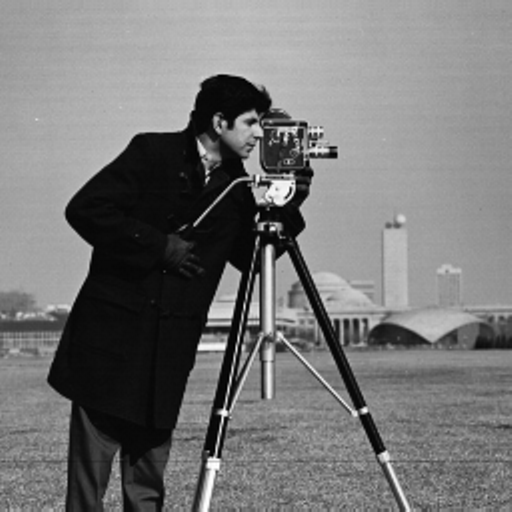

Image Format: PNG
Image Size: (512, 512)
Image Mode: L
Shape of the image array: (512, 512)


In [4]:
from PIL import Image
from IPython.display import display
import numpy as np

# open image
image_grayed = Image.open("/content/drive/MyDrive/AI ML/Data/cameraman.png")

# display image
display(image_grayed)

# image info
print("Image Format:", image_grayed.format)
print("Image Size:", image_grayed.size)
print("Image Mode:", image_grayed.mode)

# Convert to NumPy array
image_array_grayed = np.array(image_grayed)

# print shape
print("Shape of the image array:", image_array_grayed.shape)

Image shape: (1538, 1148)
Data shape for PCA: (1538, 1148)


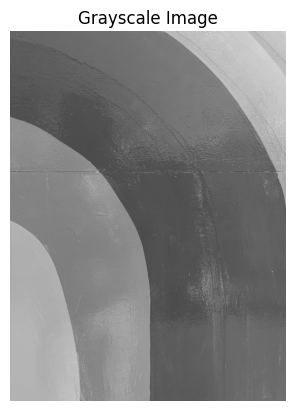

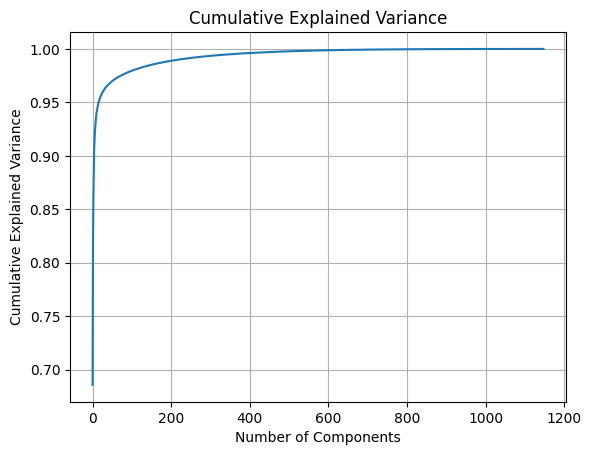

Components shape: (1148, 50)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ===============================
# Load image and convert to grayscale
# ===============================
image = Image.open(
    "/content/drive/MyDrive/AI ML/Data/image.jpg"
).convert("L")

# Convert to NumPy array
image_array = np.array(image)

# Get image dimensions
height, width = image_array.shape
print("Image shape:", image_array.shape)

# ===============================
# Prepare data for PCA
# ===============================
# Each row = one observation (already correct for grayscale)
data = image_array.astype(np.float64)

print("Data shape for PCA:", data.shape)

# Optional: display image
plt.imshow(image_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# Mean center the data
mean = np.mean(data, axis=0)
centered_data = data - mean

# Covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Plot cumulative explained variance
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()
# ===============================
# Select top k principal components
# ===============================

k = 50  # Choose k principal components

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Select top-k eigenvectors
components = eigenvectors[:, :k]

print("Components shape:", components.shape)